# Bayesian Survival Analysis — A Conceptual Introduction

This notebook provides the conceptual and mathematical foundations for the `bayes-survival` library. It is intended as a primer before working through the model-specific notebooks (`AFT_Introduction.ipynb`, `cure_model.ipynb`, etc.).

**Contents:**
1. [The Bayesian vs Frequentist Worldview](#1-the-bayesian-vs-frequentist-worldview)
2. [What is a Survival Model?](#2-what-is-a-survival-model)
3. [Applying Bayesian Inference to Survival Models](#3-applying-bayesian-inference-to-survival-models)
4. [Bayesian vs Frequentist in Practice](#4-bayesian-vs-frequentist-in-practice)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import beta as beta_dist

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

---
## 1. The Bayesian vs Frequentist Worldview

The distinction between Bayesian and frequentist statistics is how probability in interpreted.

### Frequentist View

In the frequentist framework, **parameters are fixed but unknown constants**. Data is the only source of randomness. Inference proceeds by finding the parameter value that best explains the observed data, typically via maximum likelihood estimation (MLE):

$$\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max}\ P(\text{data} \mid \theta)$$

Uncertainty is quantified using **confidence intervals**, which have a subtle frequentist interpretation: *if we repeated this experiment many times, 95% of such intervals would contain the true parameter*. This is a statement about the **procedure**, not about the probability that this particular interval contains the truth.

### Bayesian View

In the Bayesian framework, **parameters are themselves random variables** with probability distributions. We start with a **prior** $P(\theta)$ encoding our belief before seeing data, observe data, and update to a **posterior** via Bayes' theorem:

$$\underbrace{P(\theta \mid \text{data})}_{\text{posterior}} \propto \underbrace{P(\text{data} \mid \theta)}_{\text{likelihood}} \cdot \underbrace{P(\theta)}_{\text{prior}}$$

The posterior is a full probability distribution over the parameter — it represents everything we know about $\theta$ after observing the data. Uncertainty is quantified using **Highest Density Intervals (HDI)**.

### HDI vs Confidence Interval

| | Confidence Interval | Highest Density Interval |
|---|---|---|
| **Definition** | A procedure that captures $\theta$ in 95% of repeated experiments | The shortest interval containing 94% of the posterior probability mass |
| **Interpretation** | Statement about the *sampling procedure* | Direct probability statement about *this* $\theta$ |
| **What it says** | "95% of such intervals contain $\theta$" | "P($\theta \in$ HDI | data) = 0.94" |
| **Common misreading** | Often incorrectly read as an HDI | Correctly read as written |

The HDI says exactly what most people *want* a confidence interval to say. This is one of the most practically meaningful advantages of the Bayesian framework: the outputs are directly interpretable probability statements.

### Visualising Bayesian Updating

The code below demonstrates prior-to-posterior updating using a classic coin flip example. We start with a **prior** $\theta \sim \text{Beta}(2, 2)$ — a weakly informative belief that the coin is probably fair. As we observe more flips, the posterior concentrates around the true value. The frequentist MLE (proportion of heads) is shown as a vertical line.

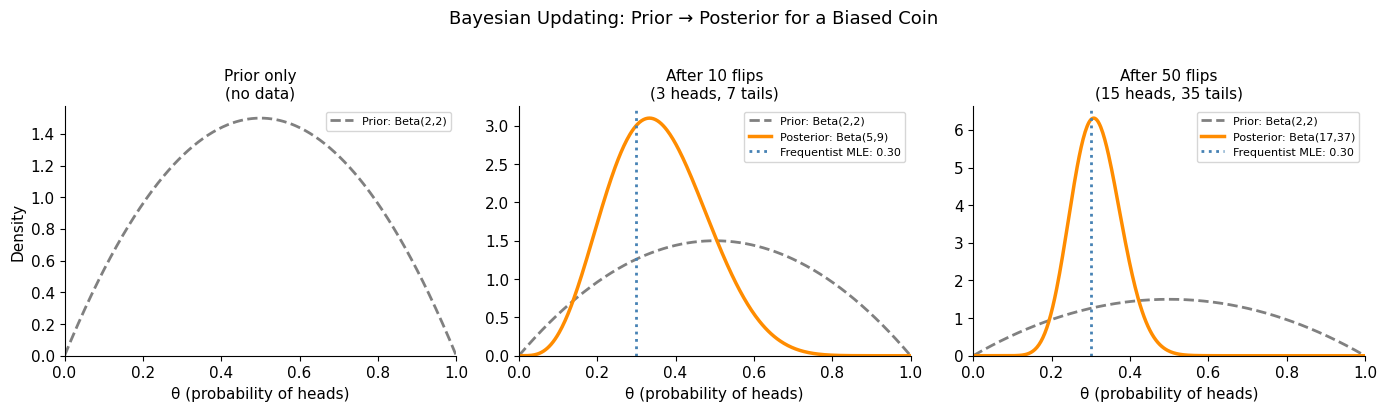

In [3]:
theta = np.linspace(0, 1, 400)
prior_a, prior_b = 2, 2  # Beta(2,2): weakly informative, centred at 0.5

scenarios = [
    (0,  0,  "Prior only\n(no data)"),
    (3,  7,  "After 10 flips\n(3 heads, 7 tails)"),
    (15, 35, "After 50 flips\n(15 heads, 35 tails)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (heads, tails, title) in zip(axes, scenarios):
    post_a = prior_a + heads
    post_b = prior_b + tails

    ax.plot(theta, beta_dist.pdf(theta, prior_a, prior_b),
            color='grey', lw=2, ls='--', label=f'Prior: Beta({prior_a},{prior_b})')

    if heads + tails > 0:
        ax.plot(theta, beta_dist.pdf(theta, post_a, post_b),
                color='darkorange', lw=2.5, label=f'Posterior: Beta({post_a},{post_b})')
        mle = heads / (heads + tails)
        ax.axvline(mle, color='steelblue', lw=2, ls=':', label=f'Frequentist MLE: {mle:.2f}')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('θ (probability of heads)')
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Density')
plt.suptitle('Bayesian Updating: Prior → Posterior for a Biased Coin', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading the plot:**
- With no data (left), the posterior equals the prior — we have only our initial belief.
- With 10 flips (centre), the posterior shifts toward the observed proportion but remains uncertain.
- With 50 flips (right), the posterior concentrates tightly around 0.3, and the MLE and posterior mean nearly coincide.

The frequentist MLE produces a single point estimate. The Bayesian posterior is a distribution that encodes *how certain* we should be about that estimate given the data we have.

---
## 2. What is a Survival Model?

### The Core Problem

Survival analysis models **time-to-event data**: how long until something happens. Examples include:

| Domain | Event |
|---|---|
| Clinical | Patient death, disease relapse, hospital readmission |
| Business | Customer churn, subscription cancellation, loan default |
| Engineering | Machine failure, component replacement |
| E-commerce | Product return, repeat purchase |

The core challenge is **censoring**: in most real studies, we stop observing before all subjects have experienced the event. We know that Subject A survived *at least* 12 months (because the study ended and they hadn't relapsed yet), but we do not know exactly when — or whether — they will relapse in the future.

**Right-censoring** is the most common type: we observe $T_i > t_i$ (the subject was still event-free at their last follow-up time $t_i$), but the exact event time is unknown.

Ignoring censored observations and analysing only the subjects who had events biases estimates downward — it makes survival look worse than it is, because we discard the evidence that some subjects survived a long time.

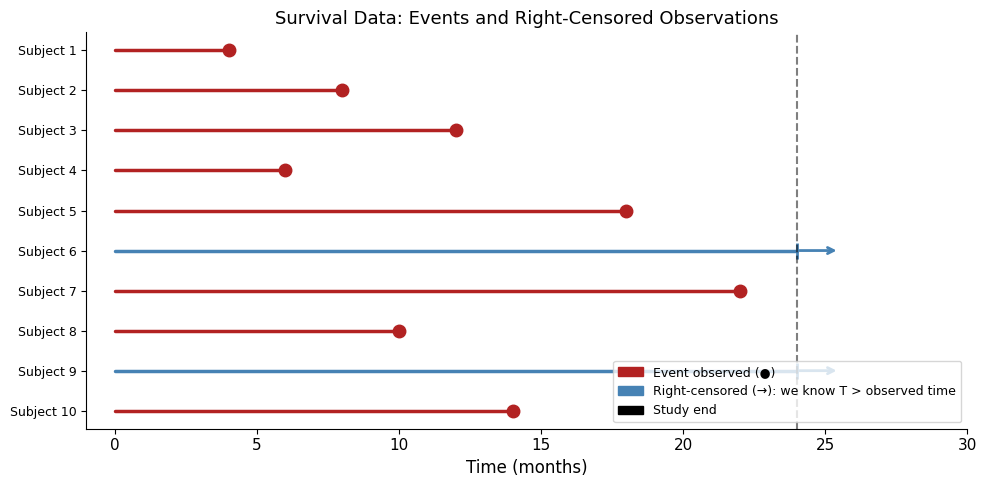

In [4]:
np.random.seed(42)
n = 10
study_end = 24  # months

# Simulated true event times and whether they occur before study end
true_event_time = np.array([4, 8, 12, 6, 18, 30, 22, 10, 35, 14], dtype=float)
observed_time   = np.minimum(true_event_time, study_end)
event_occurred  = true_event_time <= study_end

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(n):
    y = n - i
    color = 'firebrick' if event_occurred[i] else 'steelblue'
    ax.plot([0, observed_time[i]], [y, y], color=color, lw=2.5, solid_capstyle='round')

    if event_occurred[i]:
        ax.plot(observed_time[i], y, 'o', color=color, ms=9, zorder=5)
    else:
        ax.annotate('',
                    xy=(observed_time[i] + 1.5, y),
                    xytext=(observed_time[i], y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
        ax.plot(observed_time[i], y, '|', color=color, ms=12, mew=2)

ax.axvline(study_end, color='black', lw=1.5, ls='--', alpha=0.5, label='Study end')
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels([f'Subject {n - i}' for i in range(n)], fontsize=9)
ax.set_xlim(-1, study_end + 6)

event_patch  = mpatches.Patch(color='firebrick', label='Event observed (●)')
censor_patch = mpatches.Patch(color='steelblue', label='Right-censored (→): we know T > observed time')
ax.legend(handles=[event_patch, censor_patch, mpatches.Patch(color='black', label='Study end')],
          loc='lower right', fontsize=9)

ax.set_title('Survival Data: Events and Right-Censored Observations', fontsize=13)
plt.tight_layout()
plt.show()

Subjects 4 and 7 (blue arrows) have not experienced the event by study end. We do not discard them — we retain the information that they survived *at least* until the study ended, and the likelihood is constructed to account for this.

### Key Quantities

**Survival function** $S(t)$ — the probability of surviving past time $t$:
$$S(t) = P(T > t)$$

$S(t)$ is a monotonically decreasing function from 1 (at $t=0$) toward 0.

**Hazard function** $h(t)$ — the instantaneous event rate at time $t$ given survival to $t$:
$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \leq T < t + \Delta t \mid T \geq t)}{\Delta t} = -\frac{d}{dt}\log S(t)$$

The hazard can be increasing (deteriorating systems), decreasing (early high-risk period followed by stabilisation), or non-monotone.

**Relationship between $S(t)$ and $h(t)$:**
$$S(t) = \exp\!\left(-\int_0^t h(u)\,du\right)$$

Knowing one implies the other — survival models parameterise either the hazard or the survival function directly.

### Common Approaches (and what this library implements)

| Method | Type | Covariates | Notes |
|---|---|---|---|
| **Kaplan-Meier** | Non-parametric | None | Empirical step-function estimator of $S(t)$ |
| **Cox Proportional Hazards** | Semi-parametric | Yes, via hazard ratio $e^{X\beta}$ | Does not assume a baseline hazard shape |
| **Accelerated Failure Time (AFT)** | Parametric | Yes, via log-scale shift | Assumes a distributional form (Weibull, log-normal, …) |

> **Note:** Kaplan-Meier and Cox Proportional Hazards are planned TODOs for this library. The current implementation focuses on parametric AFT models.

### The AFT Framing

In an AFT model, covariates **accelerate or decelerate time** rather than shifting the hazard multiplicatively. The log of the event time is modelled as a linear function of covariates:

$$\log(T_i) = X_i\beta + \varepsilon_i$$

where $\varepsilon_i$ follows some distribution (Weibull, log-normal, …). A positive coefficient $\beta_j$ means that increasing covariate $j$ *lengthens* expected survival — interpretable as a direct multiplicative effect on time.

---
## 3. Applying Bayesian Inference to Survival Models

### How Bayesian Inference Plugs In

A parametric survival model has parameters $\theta$ (e.g., coefficients $\beta$ and shape $\alpha$). In the Bayesian setting:

1. **Priors** $P(\theta)$: encode domain knowledge or weakly informative regularisation
2. **Likelihood** $P(\text{data} \mid \theta)$: derived from the survival model, with censoring handled explicitly
3. **Posterior** $P(\theta \mid \text{data})$: obtained via MCMC sampling (e.g., NUTS in PyMC)

### The Weibull AFT Model

The Weibull AFT model — the primary model in this library — has the survival function:

$$S(t \mid x) = \exp\!\left(-\left(\frac{t}{\exp(X\beta)}\right)^\alpha\right)$$

and the corresponding density:

$$f(t \mid x) = \frac{\alpha}{\exp(X\beta)} \left(\frac{t}{\exp(X\beta)}\right)^{\alpha-1} \exp\!\left(-\left(\frac{t}{\exp(X\beta)}\right)^\alpha\right)$$

**Parameters:**
- $\beta$ — log-scale coefficients (including intercept); positive $\beta_j$ → longer expected survival
- $\alpha$ — Weibull shape: $\alpha > 1$ means increasing hazard over time (ageing), $\alpha < 1$ means decreasing hazard, $\alpha = 1$ is the exponential (constant hazard)

**Default priors** (weakly informative):
$$\alpha \sim \text{Gamma}(5, 2) \qquad \text{(mean } \approx 2.5\text{, favours increasing hazard)}$$
$$\beta_j \sim \mathcal{N}(0, 5) \qquad \text{(regularising, allows large effects)}$$

### The Censored Likelihood

The key innovation in survival likelihood is handling censored observations correctly. For $n$ subjects with observed times $t_i$ and event indicators $\delta_i \in \{0, 1\}$:

$$\mathcal{L}(\beta, \alpha \mid \mathbf{t}, \boldsymbol{\delta}) = \prod_{i=1}^n \left[f(t_i \mid x_i)\right]^{\delta_i} \cdot \left[S(t_i \mid x_i)\right]^{1 - \delta_i}$$

- If $\delta_i = 1$ (event observed): contribute the **density** $f(t_i)$ — we observed the exact event time
- If $\delta_i = 0$ (censored): contribute the **survival function** $S(t_i)$ — we know only that $T_i > t_i$

### What the Posterior Gives Us

After MCMC sampling, we have thousands of draws from the joint posterior $P(\beta, \alpha \mid \text{data})$. Each draw is a plausible set of parameters. This enables:

- **Full posterior survival curves** — not a single curve, but a distribution of curves
- **HDI bands** on predictions — direct probability intervals on $S(t \mid x)$
- **Posterior predictive event times** — simulate when future subjects will experience the event
- **Uncertainty propagation** — uncertainty in parameters flows through to uncertainty in all downstream quantities

In [5]:
import pymc as pm

# Minimal Weibull AFT model in PyMC — illustrating priors and censored likelihood.
# This mirrors the implementation in src/bayes_survival/survival_models/aft.py

# Synthetic data: 5 subjects, 3 events and 2 right-censored observations
t_obs  = np.array([5.0, 8.0, 12.0, 6.0, 15.0])
event  = np.array([1,   1,    1,    0,    0  ])
X_aug  = np.array([[1, 0.5],   # [intercept, covariate]
                   [1, 1.2],
                   [1, 0.8],
                   [1, 2.1],
                   [1, 1.7]])

# For events: upper = inf  (we observed the exact time)
# For censored: upper = t  (we know only that T > t)
upper = np.where(event == 1, np.inf, t_obs).astype(float)

with pm.Model() as weibull_aft:

    # ── Priors ──────────────────────────────────────────────────────────
    alpha = pm.Gamma("alpha", alpha=5, beta=2)          # Weibull shape
    beta  = pm.Normal("beta",  mu=0,  sigma=5, shape=2) # log-scale coefficients

    # ── Per-observation Weibull scale ────────────────────────────────────
    lam = pm.math.exp(pm.math.dot(X_aug, beta))        # lambda_i = exp(X_i @ beta)

    # ── Censored likelihood ──────────────────────────────────────────────
    # pm.Censored handles the split between f(t) and S(t) automatically:
    #   upper = inf  → log f(t)   contributed to the likelihood
    #   upper = t    → log S(t)   contributed to the likelihood
    pm.Censored(
        "obs",
        pm.Weibull.dist(alpha=alpha, beta=lam),
        lower=None,
        upper=upper,
        observed=t_obs,
    )

print("Free random variables:", [v.name for v in weibull_aft.free_RVs])
print("Observed variables  :", [v.name for v in weibull_aft.observed_RVs])
print()
print("Model is ready — call pm.sample() to draw from the posterior.")

Free random variables: ['alpha', 'beta']
Observed variables  : ['obs']

Model is ready — call pm.sample() to draw from the posterior.


The model graph above has only two free parameters (`alpha` and `beta`). In practice, `beta` has one entry per covariate plus one for the intercept. MCMC — specifically NUTS (No-U-Turn Sampler) — will explore the joint posterior over both parameters, accounting for all correlations between them.

See `AFT_Introduction.ipynb` for a fully fitted example with real data and posterior visualisations.

---
## 4. Bayesian vs Frequentist in Practice

Both approaches are valid tools. The right choice depends on data size, computational budget, the questions stakeholders are asking, and how much domain knowledge is available.

| Dimension | Frequentist | Bayesian |
|---|---|---|
| **Prior knowledge** | Cannot incorporate | Encode directly via priors |
| **Uncertainty** | Confidence intervals (frequentist semantics) | HDI (direct probability statements) |
| **Small samples** | Estimates can be unreliable or fail to converge | Priors provide regularisation |
| **Computation** | Fast: closed-form or convex optimisation (seconds) | Slower: MCMC chains (minutes to hours) |
| **Familiarity** | Standard in most applied fields | Requires Bayesian literacy to interpret |
| **Censoring** | Partial likelihood (Cox) or MLE with adjustment | Explicitly in the likelihood — same treatment |
| **Predictions** | Point estimates ± standard error | Full predictive distributions |
| **Mixture models** | Can be difficult; EM algorithm with local optima risk | Natural — latent variables sampled directly |

### When to Prefer Frequentist

- Large datasets where asymptotic guarantees hold and regularisation from priors is unnecessary
- Quick exploratory analyses or when results must be turned around rapidly
- Audiences unfamiliar with Bayesian outputs (clinical reporting, regulatory submissions)
- Computational constraints that make MCMC impractical

### When to Prefer Bayesian

- **Small or imbalanced datasets** where MLE is unstable or the likelihood is flat — priors prevent overfitting
- **Domain knowledge is available** — a clinician who knows that $\alpha > 1$ (hazard increases with age) can encode that belief rather than fitting it from data alone
- **Uncertainty matters for decisions** — when the cost of being wrong is high, having a full posterior distribution lets decision-makers quantify risk properly
- **Mixture models** such as cure models (see `cure_model.ipynb`) — latent group membership is straightforward in MCMC but awkward with EM
- **Hierarchical/multi-level structure** — partial pooling across groups is natural in PyMC

### Bayesian Models Answer the Questions People Actually Ask

A common frustration with frequentist inference is the gap between the question stakeholders ask and the answer statistics can give.

> *"What is the probability that this patient survives 5 years?"*

The frequentist answer is a point estimate of $S(5 \mid x)$ with a confidence interval that, strictly speaking, does not give a probability about this patient. The Bayesian answer is a direct posterior predictive probability: *"Given the data, there is a 72% probability of 5-year survival, with a 94% HDI of [58%, 84%]."* This is exactly what was asked.

HDIs are more legible than confidence intervals to clinicians, analysts, and decision-makers precisely because they say what people expect an interval to say. This interpretability advantage is often underappreciated as a practical argument for Bayesian methods — independent of any philosophical commitment.

### A Note on This Library

`bayes-survival` implements Bayesian AFT models in PyMC alongside frequentist equivalents from `lifelines`. Both are useful; the library exists because Bayesian methods provide richer uncertainty quantification that is particularly valuable in clinical and high-stakes business settings where the full distribution of outcomes — not just a point estimate — informs decisions.